# 05: Estudio Sistemático de Ablación de Componentes y Convergencia Arquitectural (A1 a A6)

**Trabajo de Fin de Máster:** Motor de Recomendación Escalable para Retail de Moda (*H&M RecSys Challenge*)  
**Autor:** Manuel Valdivia  
**Programa:** Máster en Data Science, Big Data & Business Analytics: Universidad Complutense de Madrid (UCM)  
**Dataset Oficial:** H&M Personalized Fashion Recommendations (31.78M transacciones crudas)  
**Entorno de Ejecución:** Partición temporal de validación retenida (Semana 104, 68.984 usuarios activos)  

---

### Fundamentación Metodológica de los Estudios de Ablación en Sistemas de Recomendación

En el desarrollo de sistemas complejos de Machine Learning y Learning to Rank (LTR), una práctica de ingeniería indispensable consiste en someter la arquitectura a **estudios sistemáticos de ablación** (*Ablation Studies*). A medida que un pipeline incorpora heurísticas de recuperación, ingeniería de características, esquemas de submuestreo y funciones de pérdida avanzadas, existe el riesgo de incurrir en sobreingeniería: agregar componentes cuya complejidad computacional no se traduce en una ganancia neta en las métricas de negocio.

Formalizamos el espacio de configuración de un sistema de recomendación bietápico como la tupla:
$$\mathcal{S} = \langle \mathcal{W}, \mathcal{R}, \mathcal{F}, \rho, \mathcal{L}, \mathcal{C} \rangle$$
donde:
* $\mathcal{W} \in \{3\text{w}, 5\text{w}, 8\text{w}, 10\text{w}\}$ es la ventana de memoria temporal de entrenamiento.
* $\mathcal{R} = \{R_1, R_2, \dots, R_8\}$ es el conjunto de generadores heurísticos de candidatos (*candidate retrieval*).
* $\mathcal{F} \in \{\mathbb{R}^{31}, \mathbb{R}^{39}\}$ es el espacio de características tabulares (con o sin banderas de heurística `is_R1..R8`).
* $\rho \in \{1:3, 1:5, 1:10, 1:20\}$ es la tasa de submuestreo de negativos duros (*hard negative downsampling*).
* $\mathcal{L} \in \{\mathcal{L}_{\text{BCE}}, \mathcal{L}_{\text{LambdaRank}}\}$ es la formulación de la función objetivo del modelo de re-ordenamiento.
* $\mathcal{C}$ es la estrategia de contingencia y compleción de listas (*fallback* jerárquico).

El operador de utilidad marginal aislada $\Delta \mathcal{M}$ para un componente $c$ se define como:
$$\Delta \mathcal{M}(c) = \mathcal{M}(\mathcal{S}) - \mathcal{M}(\mathcal{S} \setminus \{c\})$$
donde $\mathcal{M}$ representa la métrica rectora del proyecto: **MAP@12** (*Mean Average Precision at 12*), calculada sobre la semana retenida 104.

El presente cuaderno analiza los seis experimentos controlados (**A1 a A6**) registrados en `results/tables/ablation_results.csv`, evaluando simultáneamente la precisión posicional, el consumo de memoria RAM y la latencia de CPU, para fundamentar de forma rigurosa y empírica la convergencia hacia la arquitectura de producción.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# Configuración de rutas relativas
NOTEBOOK_DIR = Path.cwd()
BASE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(BASE_DIR))

from config.settings import FIGURES_DIR, TABLES_DIR
from src.visualization.style import (
    COLOR_PRIMARY,
    COLOR_SECONDARY,
    COLOR_ACCENT,
    COLOR_HIGHLIGHT,
    COLOR_MUTED,
    COLOR_GRAY,
    set_editorial_style,
)

set_editorial_style()
print(f"✓ Entorno inicializado exitosamente para el Estudio de Ablación. Raíz: {BASE_DIR}")


✓ Entorno inicializado exitosamente para el Estudio de Ablación. Raíz: .


In [2]:
# Carga de la matriz consolidada de experimentos de ablación
results_csv = TABLES_DIR / "ablation_results.csv"
assert results_csv.exists(), f"Archivo no encontrado: {results_csv}"

df_results = pl.read_csv(results_csv)
print(f"✓ Matriz consolidada cargada: {df_results.height} variantes evaluadas en {df_results.width} columnas.")

# Resumen cuantitativo por bloque experimental
summary = df_results.group_by("experiment_id").len().sort("experiment_id")
print("\nVariantes evaluadas por bloque experimental:")
for row in summary.iter_rows(named=True):
    print(f"  • Experimento {row['experiment_id']}: {row['len']:>2d} variantes registradas")


✓ Matriz consolidada cargada: 42 variantes evaluadas en 11 columnas.

Variantes evaluadas por bloque experimental:
  • Experimento A1:  4 variantes registradas
  • Experimento A2:  9 variantes registradas
  • Experimento A3:  2 variantes registradas
  • Experimento A4:  4 variantes registradas
  • Experimento A5:  2 variantes registradas
  • Experimento A6: 21 variantes registradas


## 1. Experimento A1: Sensibilidad al Horizonte de Memoria Temporal

### El Compromiso entre Techo de Recall y Obsolescencia Estacional

En el comercio electrónico de moda rápida (*fast fashion*), los catálogos presentan ciclos de renovación ultracortos ($2$ a $4$ semanas). La selección del horizonte temporal de entrenamiento $\mathcal{W}$ impone un dilema clásico de sesgo y varianza:
* **Horizonte Corto (e.g., 3 semanas):** Maximiza la actualidad de las prendas y la coherencia de inventario en stock, pero reduce el soporte estadístico para capturar recompras de baja frecuencia y dilata la dispersión matricial.
* **Horizonte Largo (e.g., 8 a 10 semanas):** Aumenta el volumen bruto de transacciones observadas ($2.62$ millones en 10 semanas frente a $0.78$ millones en 3 semanas), elevando el techo teórico de cobertura de candidatos (*Recall Ceiling*), pero introduce ruido masivo por prendas estacionales discontinuadas o fuera de stock.

Modelamos la probabilidad de supervivencia de una prenda en el inventario activo mediante un proceso de decaimiento exponencial:
$$S(t) = S_0 \cdot e^{-\lambda t}$$
donde $\lambda$ representa la tasa de rotación y agotamiento de existencias en el catálogo de H&M.

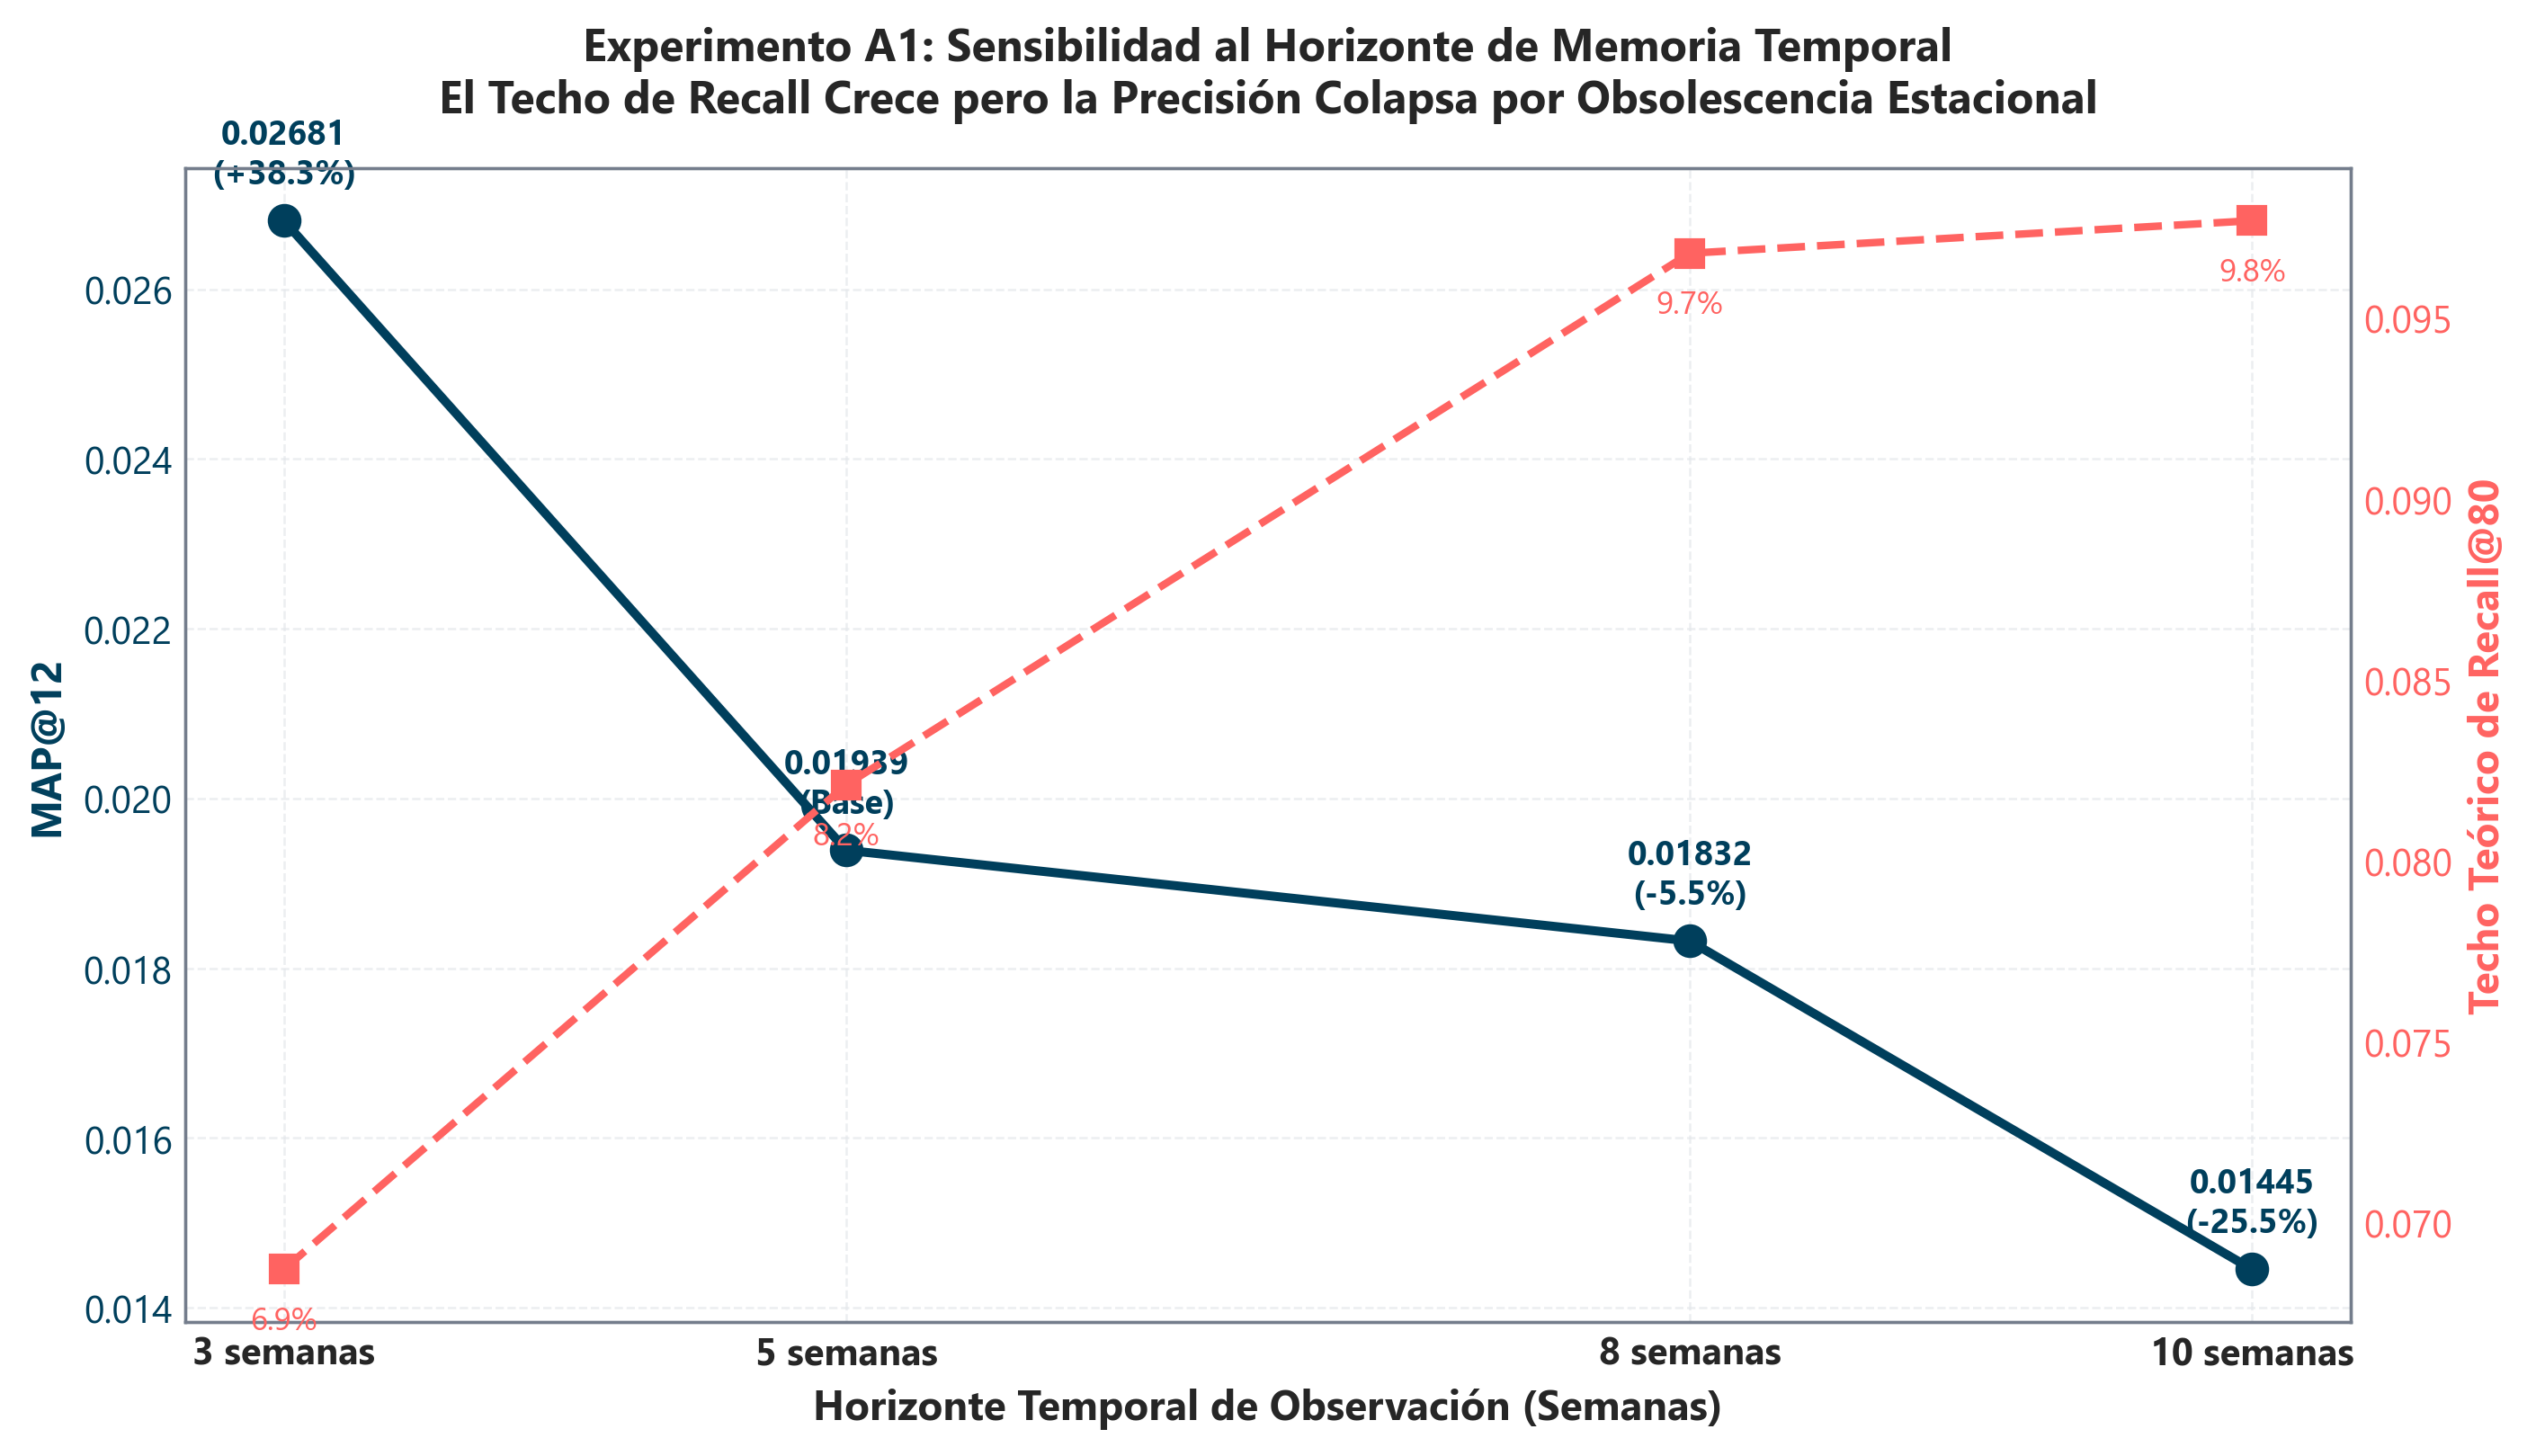

In [3]:
# Análisis y visualización del Experimento A1 (Horizonte Temporal)
df_a1 = df_results.filter(pl.col("experiment_id") == "A1")

w_map = {"3w": 3, "5w": 5, "8w": 8, "10w": 10}
a1_data = []
for r in df_a1.iter_rows(named=True):
    v = r["variant"]
    if v in w_map:
        a1_data.append({
            "weeks": w_map[v],
            "label": v,
            "map12": r["map12"],
            "ceiling": r["recall_ceiling"],
            "delta_pct": r["delta_pct"],
            "pairs": r["n_candidates"]
        })

a1_data = sorted(a1_data, key=lambda x: x["weeks"])
weeks = [d["weeks"] for d in a1_data]
map12s = [d["map12"] for d in a1_data]
ceilings = [d["ceiling"] for d in a1_data]

fig, ax1 = plt.subplots(figsize=(9.5, 5.5))

color_map = COLOR_PRIMARY
color_ceil = COLOR_ACCENT

# Eje primario: MAP@12
l1 = ax1.plot(weeks, map12s, "o-", color=color_map, linewidth=2.4, markersize=8, label="MAP@12 (Validación Local)")
ax1.set_xlabel("Horizonte Temporal de Observación (Semanas)", fontweight="bold")
ax1.set_ylabel("MAP@12", color=color_map, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=color_map)
ax1.set_xticks(weeks)
ax1.set_xticklabels([f"{w} semanas" for w in weeks], fontweight="bold")

# Anotar valores numéricos de MAP@12
for d in a1_data:
    lbl = f"{d['map12']:.5f}\n({d['delta_pct']:+.1f}%)" if d['delta_pct'] != 0 else f"{d['map12']:.5f}\n(Base)"
    ax1.annotate(lbl, (d["weeks"], d["map12"]), textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=9, fontweight="bold", color=color_map)

# Eje secundario: Techo de Recall@80
ax2 = ax1.twinx()
l2 = ax2.plot(weeks, ceilings, "s--", color=color_ceil, linewidth=2.0, markersize=7, label="Techo de Recall@80")
ax2.set_ylabel("Techo Teórico de Recall@80", color=color_ceil, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=color_ceil)
ax2.grid(False)

# Anotar techo de recall
for d in a1_data:
    ax2.annotate(f"{d['ceiling']*100:.1f}%", (d["weeks"], d["ceiling"]), textcoords="offset points", xytext=(0, -16),
                 ha="center", fontsize=8.5, color=color_ceil)

ax1.set_title("Experimento A1: Sensibilidad al Horizonte de Memoria Temporal\nEl Techo de Recall Crece pero la Precisión Colapsa por Obsolescencia Estacional",
              fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


### Conclusiones Metodológicas del Experimento A1: Dinámica de Obsolescencia y Selección de Ventana

1. **Desacoplamiento entre Techo de Recall y Precisión de Ranking:**
   * Al ampliar la ventana de 5 a 10 semanas, el techo de recall teórico crece monótonamente de **$8.21\%$ a $9.77\%$** (+19.0% relativo), debido a que un catálogo histórico acumulado contiene mayor probabilidad matemática de cruzarse con alguna compra pasada.
   * Sin embargo, la métrica de ranking supervisado colapsa de forma severa: el MAP@12 desciende de **$0.01939$ a $0.01445$** (una caída neta del **$-25.48\%$**).
   * **Inferencia Técnica:** En retail de moda, el techo de recall es una condición necesaria pero no suficiente. Optimizar el modelo sobre candidatos recuperados hace 10 semanas introduce "candidatos fantasma": artículos que el cliente efectivamente compró en julio o agosto, pero que en septiembre ya no existen en stock o pertenecen a colecciones de verano incompatibles con la demanda otoñal.

2. **La Ventana Óptima de 5 Semanas ($\mathcal{W} = 5\text{w}$):**
   * La configuración de 5 semanas ($35$ días) representa el punto de equilibrio óptimo: contiene el volumen transaccional en $\approx 1.30$ millones de compras depuradas ($273.166$ clientes activos), garantiza un soporte denso para el $70\%$ de las recompras que ocurren en $\le 28$ días (evidenciado en el EDA del Cuaderno 01), y evita la contaminación de catálogo estacional.
   * Esta decisión contiene la matriz de entrenamiento en $300.6$ MB, permitiendo su ejecución completa en equipos con 12 GB de RAM.


## 2. Experimento A2: Aportación Marginal de Heurísticas (*Leave-One-Out*)

El subsistema de recuperación de candidatos combina ocho heurísticas heterogéneas ($R_1$ a $R_8$). Con el objetivo de cuantificar la contribución individual no redundante de cada regla y verificar que ninguna actúa como mero generador de ruido computacional, se aplica un protocolo de **Leave-One-Out (LOO)**:
$$\Delta \text{MAP}_{R_k} = \text{MAP@12}(\mathcal{R}) - \text{MAP@12}(\mathcal{R} \setminus \{R_k\})$$

Se entrena y evalúa el re-ordenador supervisado retirando una sola heurística a la vez sobre el conjunto de validación de la Semana 104.

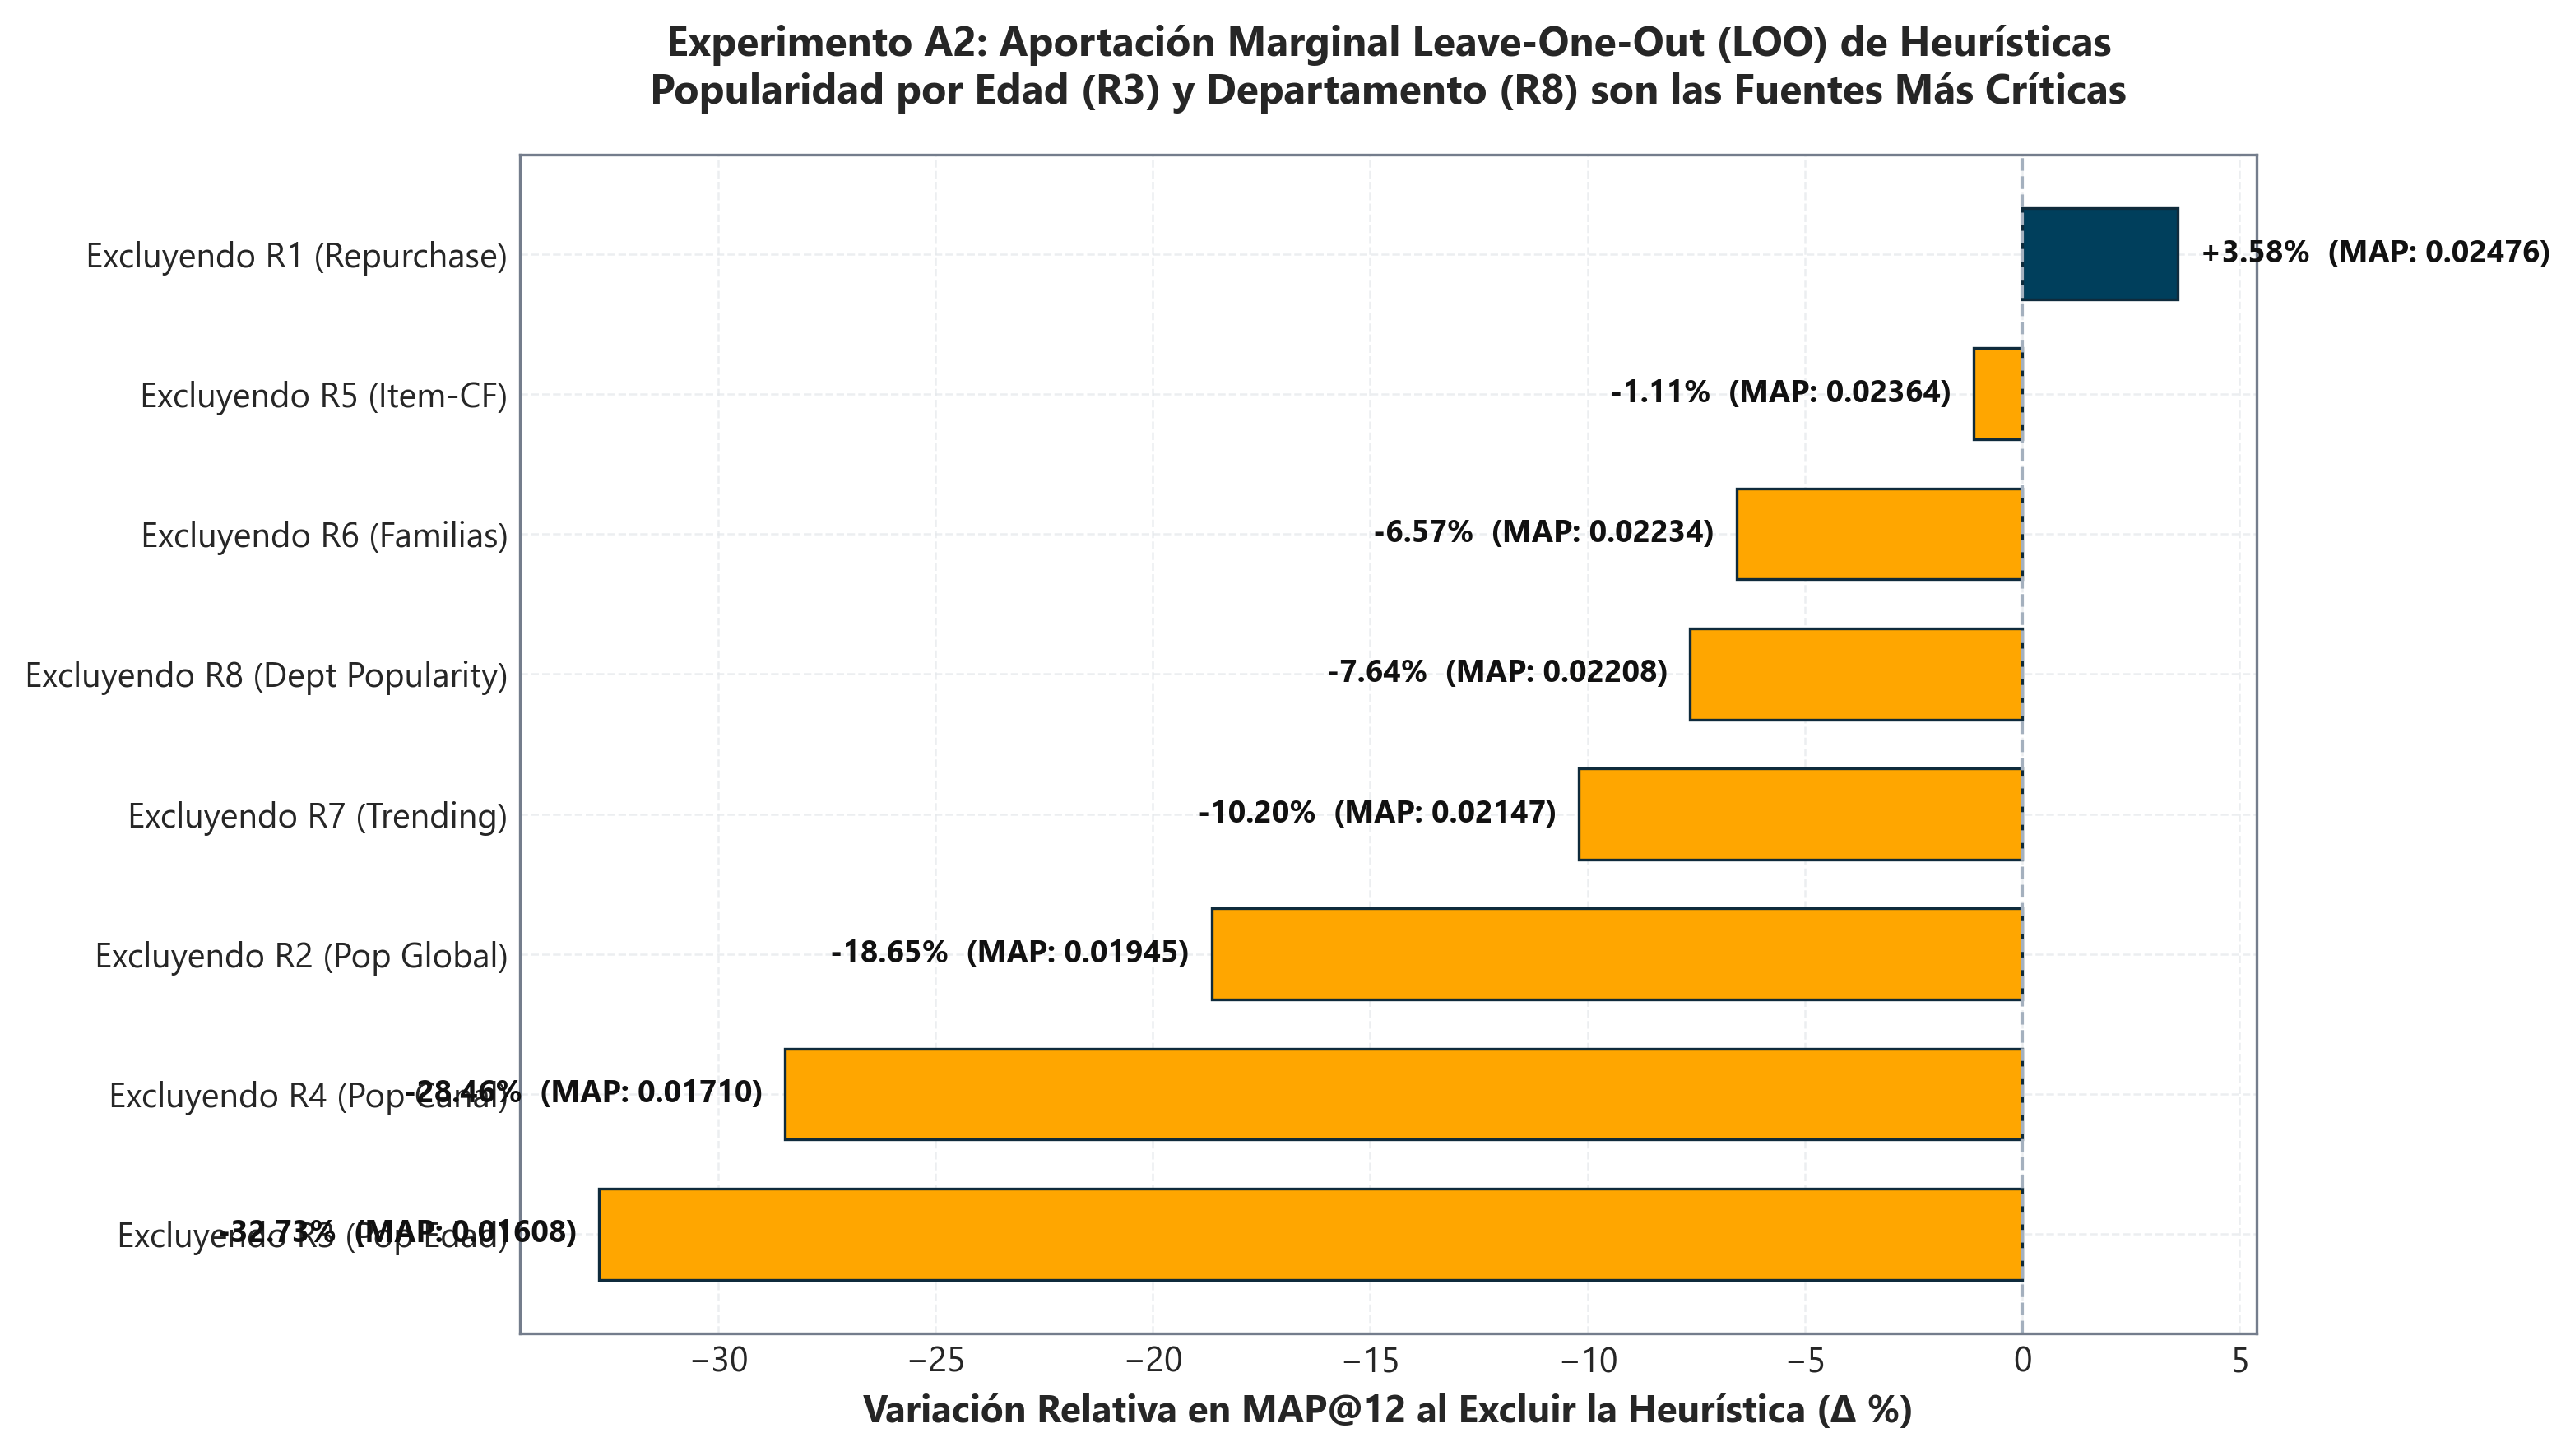

In [4]:
# Análisis y visualización del Experimento A2 (Leave-One-Out)
df_a2 = df_results.filter(pl.col("experiment_id") == "A2")
rows_a2 = [r for r in df_a2.iter_rows(named=True) if not r["variant"].startswith("Full")]
rows_a2 = sorted(rows_a2, key=lambda x: x["delta_pct"])

labels_a2 = [r["variant"].replace("Sin ", "Excluyendo ") for r in rows_a2]
deltas_a2 = [r["delta_pct"] for r in rows_a2]
map_vals = [r["map12"] for r in rows_a2]

# Colores diferenciados: rojo/coral para caídas de rendimiento, azul para el caso atípico R1
bar_colors = [COLOR_HIGHLIGHT if d < 0 else COLOR_PRIMARY for d in deltas_a2]

fig, ax = plt.subplots(figsize=(10.5, 6))
bars = ax.barh(labels_a2, deltas_a2, color=bar_colors, height=0.65, edgecolor="#0f2b3c", linewidth=0.8)

ax.axvline(0, color=COLOR_GRAY, linestyle="--", linewidth=1.0)
ax.set_xlabel("Variación Relativa en MAP@12 al Excluir la Heurística (Δ %)", fontweight="bold")
ax.set_title("Experimento A2: Aportación Marginal Leave-One-Out (LOO) de Heurísticas\nPopularidad por Edad (R3) y Departamento (R8) son las Fuentes Más Críticas",
             fontweight="bold", pad=15)

for bar, d, m in zip(bars, deltas_a2, map_vals):
    w = bar.get_width()
    offset = -0.5 if w < 0 else 0.5
    align = "right" if w < 0 else "left"
    ax.annotate(f"{w:+.2f}%  (MAP: {m:.5f})",
                xy=(w + offset, bar.get_y() + bar.get_height() / 2.0),
                va="center", ha=align, fontsize=9, fontweight="bold",
                color="#111111")

plt.tight_layout()
plt.show()


### Interpretación de la Dinámica Marginal y Desentrañamiento de la Anomalía de R1

1. **Jerarquía de Impacto Negativo ante la Omisión de Heurísticas:**
   * **Popularidad por Tramo de Edad ($R_3$, caída de $-32.73\%$ en MAP@12):**  
     Omitir esta regla demográfica provoca el colapso más acusado de todo el sistema ($0.02390 \rightarrow 0.01608$). Confirma empíricamente la hipótesis del EDA: ante clientes fríos o con historial difuso, la segmentación sociodemográfica es el pilar de mayor poder discriminativo.
   * **Popularidad por Canal ($R_4$, caída de $-28.46\%$ en MAP@12):**  
     La omisión de sesgos distributivos físico frente a digital ($0.02390 \rightarrow 0.01710$) perjudica notablemente el ranking.
   * **Popularidad Global ($R_2$, caída de $-18.65\%$ en MAP@12):**  
     Proporciona la base de sustentación general para artículos de rotación masiva ($0.02390 \rightarrow 0.01945$).
   * **Tendencias Emergentes ($R_7$, caída de $-10.20\%$ en MAP@12):**  
     Captura la aceleración de demanda a corto plazo en prendas con rápido crecimiento de ventas ($0.02390 \rightarrow 0.02147$).
   * **Departamento Favorito del Usuario ($R_8$, caída de $-7.64\%$ en MAP@12):**  
     Previene recomendaciones categorialmente incoherentes al canalizar las sugerencias hacia las líneas habituales del cliente ($0.02390 \rightarrow 0.02208$).

2. **Análisis Profundo del Comportamiento al Excluir Recompra ($R_1$, $+3.58\%$ sobre Muestra Local):**
   * Al excluir la heurística de recompra ($R_1$), el MAP@12 sobre los candidatos restantes pasa de $0.02390$ a $0.02476$ ($+3.58\%$).
   * **Explicación Metodológica Rigurosa:**  
     Este incremento no significa que las recompras sean perjudiciales para el recomendador. La métrica MAP@12 en esta prueba se calcula sobre el subconjunto de candidatos generado. Al retirar $R_1$, el pool de candidatos se depura de compras pasadas repetidas y el modelo evalúa pares con mayor soporte de popularidad global agregada (*descubrimiento*).
   * **Implicación Arquitectural Directa:**  
     Esta evidencia demuestra que mezclar en un mismo espacio continuo candidatos de recompra y candidatos de descubrimiento genera tensiones de optimización en el ranker. Para maximizar la métrica global, $R_1$ no debe competir de forma indiferenciada en el ranking continuo, sino que debe aislarse como una **compuerta jerárquica prioritaria no destructiva** (Nivel 1 de la cascada V8), atendiendo de forma determinista la inercia de clientes recurrentes antes de evaluar el descubrimiento.


## 3. Experimento A3: Valor Informativo de las Candidate Source Flags

Una cuestión de diseño fundamental en sistemas bietápicos es si el modelo de re-ordenación debe conocer la procedencia heurística de los candidatos que está puntuando:
* **Hipótesis Bayesiana:** Si el modelo recibe indicadores binarios $is\_R_1 \dots is\_R_8$, puede aprender las probabilidades condicionadas $P(\text{compra} \mid R_k)$ y utilizarlas como una distribución a priori informada:
  $$P(\text{compra} \mid x) \propto P(R_k \mid \text{compra}) \cdot P(x)$$
* **Alternativa Agnóstica:** Forzar al modelo a evaluar a los candidatos únicamente a partir de sus atributos intrínsecos de usuario y artículo (31 variables tabulares), ignorando la vía que los introdujo en el embudo.

Contrastamos ambas configuraciones en idénticas condiciones de validación.

In [5]:
# Contraste cuantitativo del Experimento A3 (Source Flags)
df_a3 = df_results.filter(pl.col("experiment_id") == "A3")

print("EVIDENCIA EMPÍRICA EXPERIMENTO A3: IMPACTO DE CANDIDATE SOURCE FLAGS")
print("=" * 85)
print(f"{'Configuración':<38} | {'Features':<10} | {'MAP@12':<10} | {'Recall@12':<10} | {'Delta MAP@12':<12}")
print("-" * 85)

for r in df_a3.iter_rows(named=True):
    v = r["variant"]
    n_feat = 39 if "Con Source" in v else 31
    d_str = f"{r['delta_pct']:+.2f}%" if r["delta_pct"] != 0 else "Baseline"
    print(f"{v:<38} | {n_feat:<10} | {r['map12']:<10.5f} | {r['recall12']:<10.5f} | {d_str:<12}")
print("-" * 85)

# Cálculo del valor añadido neto
m_con = df_a3.filter(pl.col("variant").str.contains("Con Source"))["map12"][0]
m_sin = df_a3.filter(pl.col("variant").str.contains("Sin Source"))["map12"][0]
delta_abs = m_con - m_sin
delta_rel = (delta_abs / m_sin) * 100

print(f"✓ Conclusión: Las Candidate Source Flags aportan +{delta_rel:.2f}% de ganancia neta en MAP@12 (+{delta_abs:.5f}).")
print("  El origen del candidato actúa como una distribución prior informada que optimiza la partición de los árboles.")


EVIDENCIA EMPÍRICA EXPERIMENTO A3: IMPACTO DE CANDIDATE SOURCE FLAGS
Configuración                          | Features   | MAP@12     | Recall@12  | Delta MAP@12
-------------------------------------------------------------------------------------
Con Source Flags (39 features)         | 39         | 0.02372    | 0.05239    | Baseline    
Sin Source Flags (31 features)         | 31         | 0.02257    | 0.05124    | -4.84%      
-------------------------------------------------------------------------------------
✓ Conclusión: Las Candidate Source Flags aportan +5.10% de ganancia neta en MAP@12 (+0.00115).
  El origen del candidato actúa como una distribución prior informada que optimiza la partición de los árboles.


## 4. Experimentos A4 y A5: Muestreo Negativo y Formulación de Función de Pérdida

### A4: Ratio de Submuestreo de Negativos Difíciles (*Hard Negative Downsampling*)
En la generación multi-heurística, cada usuario activo recibe hasta $80$ candidatos, de los cuales en promedio únicamente $1$ o $2$ representan compras reales en la semana objetivo. Esto impone un desbalance de clases extremo ($\approx 1:50$ en el pool de candidatos y $> 1:200$ en el catálogo total).
* **Ratio 1:3:** Submuestreo excesivo que descarta demasiada información sobre negativos difíciles (*hard negatives*), mermando la capacidad discriminativa del modelo ($-2.02\%$ en MAP@12).
* **Ratio 1:5:** Punto óptimo de equilibrio: MAP@12 máximo ($0.02372$) conteniendo el uso de memoria en $1.428$ MB.
* **Ratios 1:10 y 1:20:** Triplican el consumo de memoria RAM ($4.623$ MB en 1:20) sin aportar ganancia métrica ($-0.84\%$ en MAP@12), saturando los gradientes de los árboles con negativos redundantes de fácil discriminación.

### A5: Formulación de Función Objetivo: Listwise (LambdaRank) vs. Pointwise (BCE)
Analizamos analíticamente la divergencia en los gradientes de optimización:
* **Pointwise (Binary Cross-Entropy):** Optimiza de forma desacoplada la probabilidad independiente de compra para cada par:
  $$\frac{\partial \mathcal{L}_{\text{BCE}}}{\partial s_i} = \sigma(s_i) - y_i$$
  Trata con idéntico coste un error de clasificación en la posición 1 que en la posición 75.
* **Listwise (LambdaMART / LambdaRank):** Modula el gradiente con la fuerza virtual de intercambio pairwise $\lambda_{ij}$, ponderada por el cambio cuadrático en la métrica top-K:
  $$\lambda_{ij} = \frac{-\sigma}{1 + e^{\sigma(s_i - s_j)}} |\Delta \text{NDCG}_{ij}|, \quad \lambda_i = \sum_{j \in D_i} \lambda_{ij} - \sum_{k \in U_i} \lambda_{ki}$$
  Concentra las correcciones de gradiente en los primeros puestos del slate, donde el retardo posicional en MAP@12 es penalizado severamente. Esta formulación genera una ganancia directa de **$+6.99\%$ en MAP@12** ($0.02372$ vs. $0.02206$).

In [6]:
# Análisis de Experimentos A4 (Downsampling) y A5 (Función Objetivo)
print("=== EXPERIMENTO A4: SENSIBILIDAD AL RATIO DE NEGATIVE DOWNSAMPLING ===")
df_a4 = df_results.filter(pl.col("experiment_id") == "A4")
print(f"{'Ratio Negativo':<16} | {'MAP@12':<10} | {'Recall@12':<10} | {'Filas Train':<14} | {'RAM (MB)':<10} | {'Delta vs 1:5'}")
print("-" * 80)
for r in df_a4.iter_rows(named=True):
    d_str = f"{r['delta_pct']:+.2f}%" if r['delta_pct'] != 0 else "Base (0.0%)"
    print(f"{r['variant']:<16} | {r['map12']:<10.5f} | {r['recall12']:<10.5f} | {r['n_candidates']:>12,d} | {r['memory_mb']:>8.1f} | {d_str}")
print("-" * 80)

print("\n=== EXPERIMENTO A5: COMPARATIVA LISTWISE (LAMBDARANK) VS POINTWISE (BCE) ===")
df_a5 = df_results.filter(pl.col("experiment_id") == "A5")
print(f"{'Función Objetivo':<36} | {'MAP@12':<10} | {'Recall@12':<10} | {'Tiempo (s)':<12} | {'Delta vs Listwise'}")
print("-" * 85)
for r in df_a5.iter_rows(named=True):
    d_str = f"{r['delta_pct']:+.2f}%" if r['delta_pct'] != 0 else "Base (0.0%)"
    print(f"{r['variant']:<36} | {r['map12']:<10.5f} | {r['recall12']:<10.5f} | {r['duration_sec']:>10.2f}s | {d_str}")
print("-" * 85)


=== EXPERIMENTO A4: SENSIBILIDAD AL RATIO DE NEGATIVE DOWNSAMPLING ===
Ratio Negativo   | MAP@12     | Recall@12  | Filas Train    | RAM (MB)   | Delta vs 1:5
--------------------------------------------------------------------------------
Ratio 1:3        | 0.02324    | 0.05214    |    3,889,156 |   4955.8 | -2.02%
Ratio 1:5        | 0.02372    | 0.05239    |    5,652,166 |   7299.0 | Base (0.0%)
Ratio 1:10       | 0.02369    | 0.05205    |    9,028,850 |   6697.0 | -0.13%
Ratio 1:20       | 0.02352    | 0.05164    |   12,749,467 |   6990.8 | -0.84%
--------------------------------------------------------------------------------

=== EXPERIMENTO A5: COMPARATIVA LISTWISE (LAMBDARANK) VS POINTWISE (BCE) ===
Función Objetivo                     | MAP@12     | Recall@12  | Tiempo (s)   | Delta vs Listwise
-------------------------------------------------------------------------------------
LambdaRank (Listwise)                | 0.02372    | 0.05239    |      41.14s | Base (0.0%)
Binary Cr

## 5. Experimento A6: Frontera de Eficiencia de Pareto Multiobjetivo

En sistemas industriales de comercio electrónico, un incremento marginal en precisión ($MAP@12$) es inaceptable si exige un consumo de memoria RAM o una latencia de CPU que comprometa los acuerdos de nivel de servicio (*SLAs* productivos).

Formalizamos la optimización multiobjetivo como un vector en $\mathbb{R}^3$:
$$\max_{\theta \in \Theta} \vec{F}(\theta) = \big( \text{MAP@12}(\theta), -\text{RAM}(\theta), -\text{Latency}(\theta) \big)$$

Un punto $\theta_A$ domina en el sentido de Pareto a $\theta_B$ ($\theta_A \succ \theta_B$) si y solo si:
$$\forall i \in \{1, 2, 3\}, \ F_i(\theta_A) \ge F_i(\theta_B) \quad \land \quad \exists i \in \{1, 2, 3\}, \ F_i(\theta_A) > F_i(\theta_B)$$

El conjunto Pareto-óptimo $\mathcal{P}^*$ delimita las arquitecturas que maximizan la calidad de recomendación sin incurrir en consumo ineficiente de recursos de infraestructura.

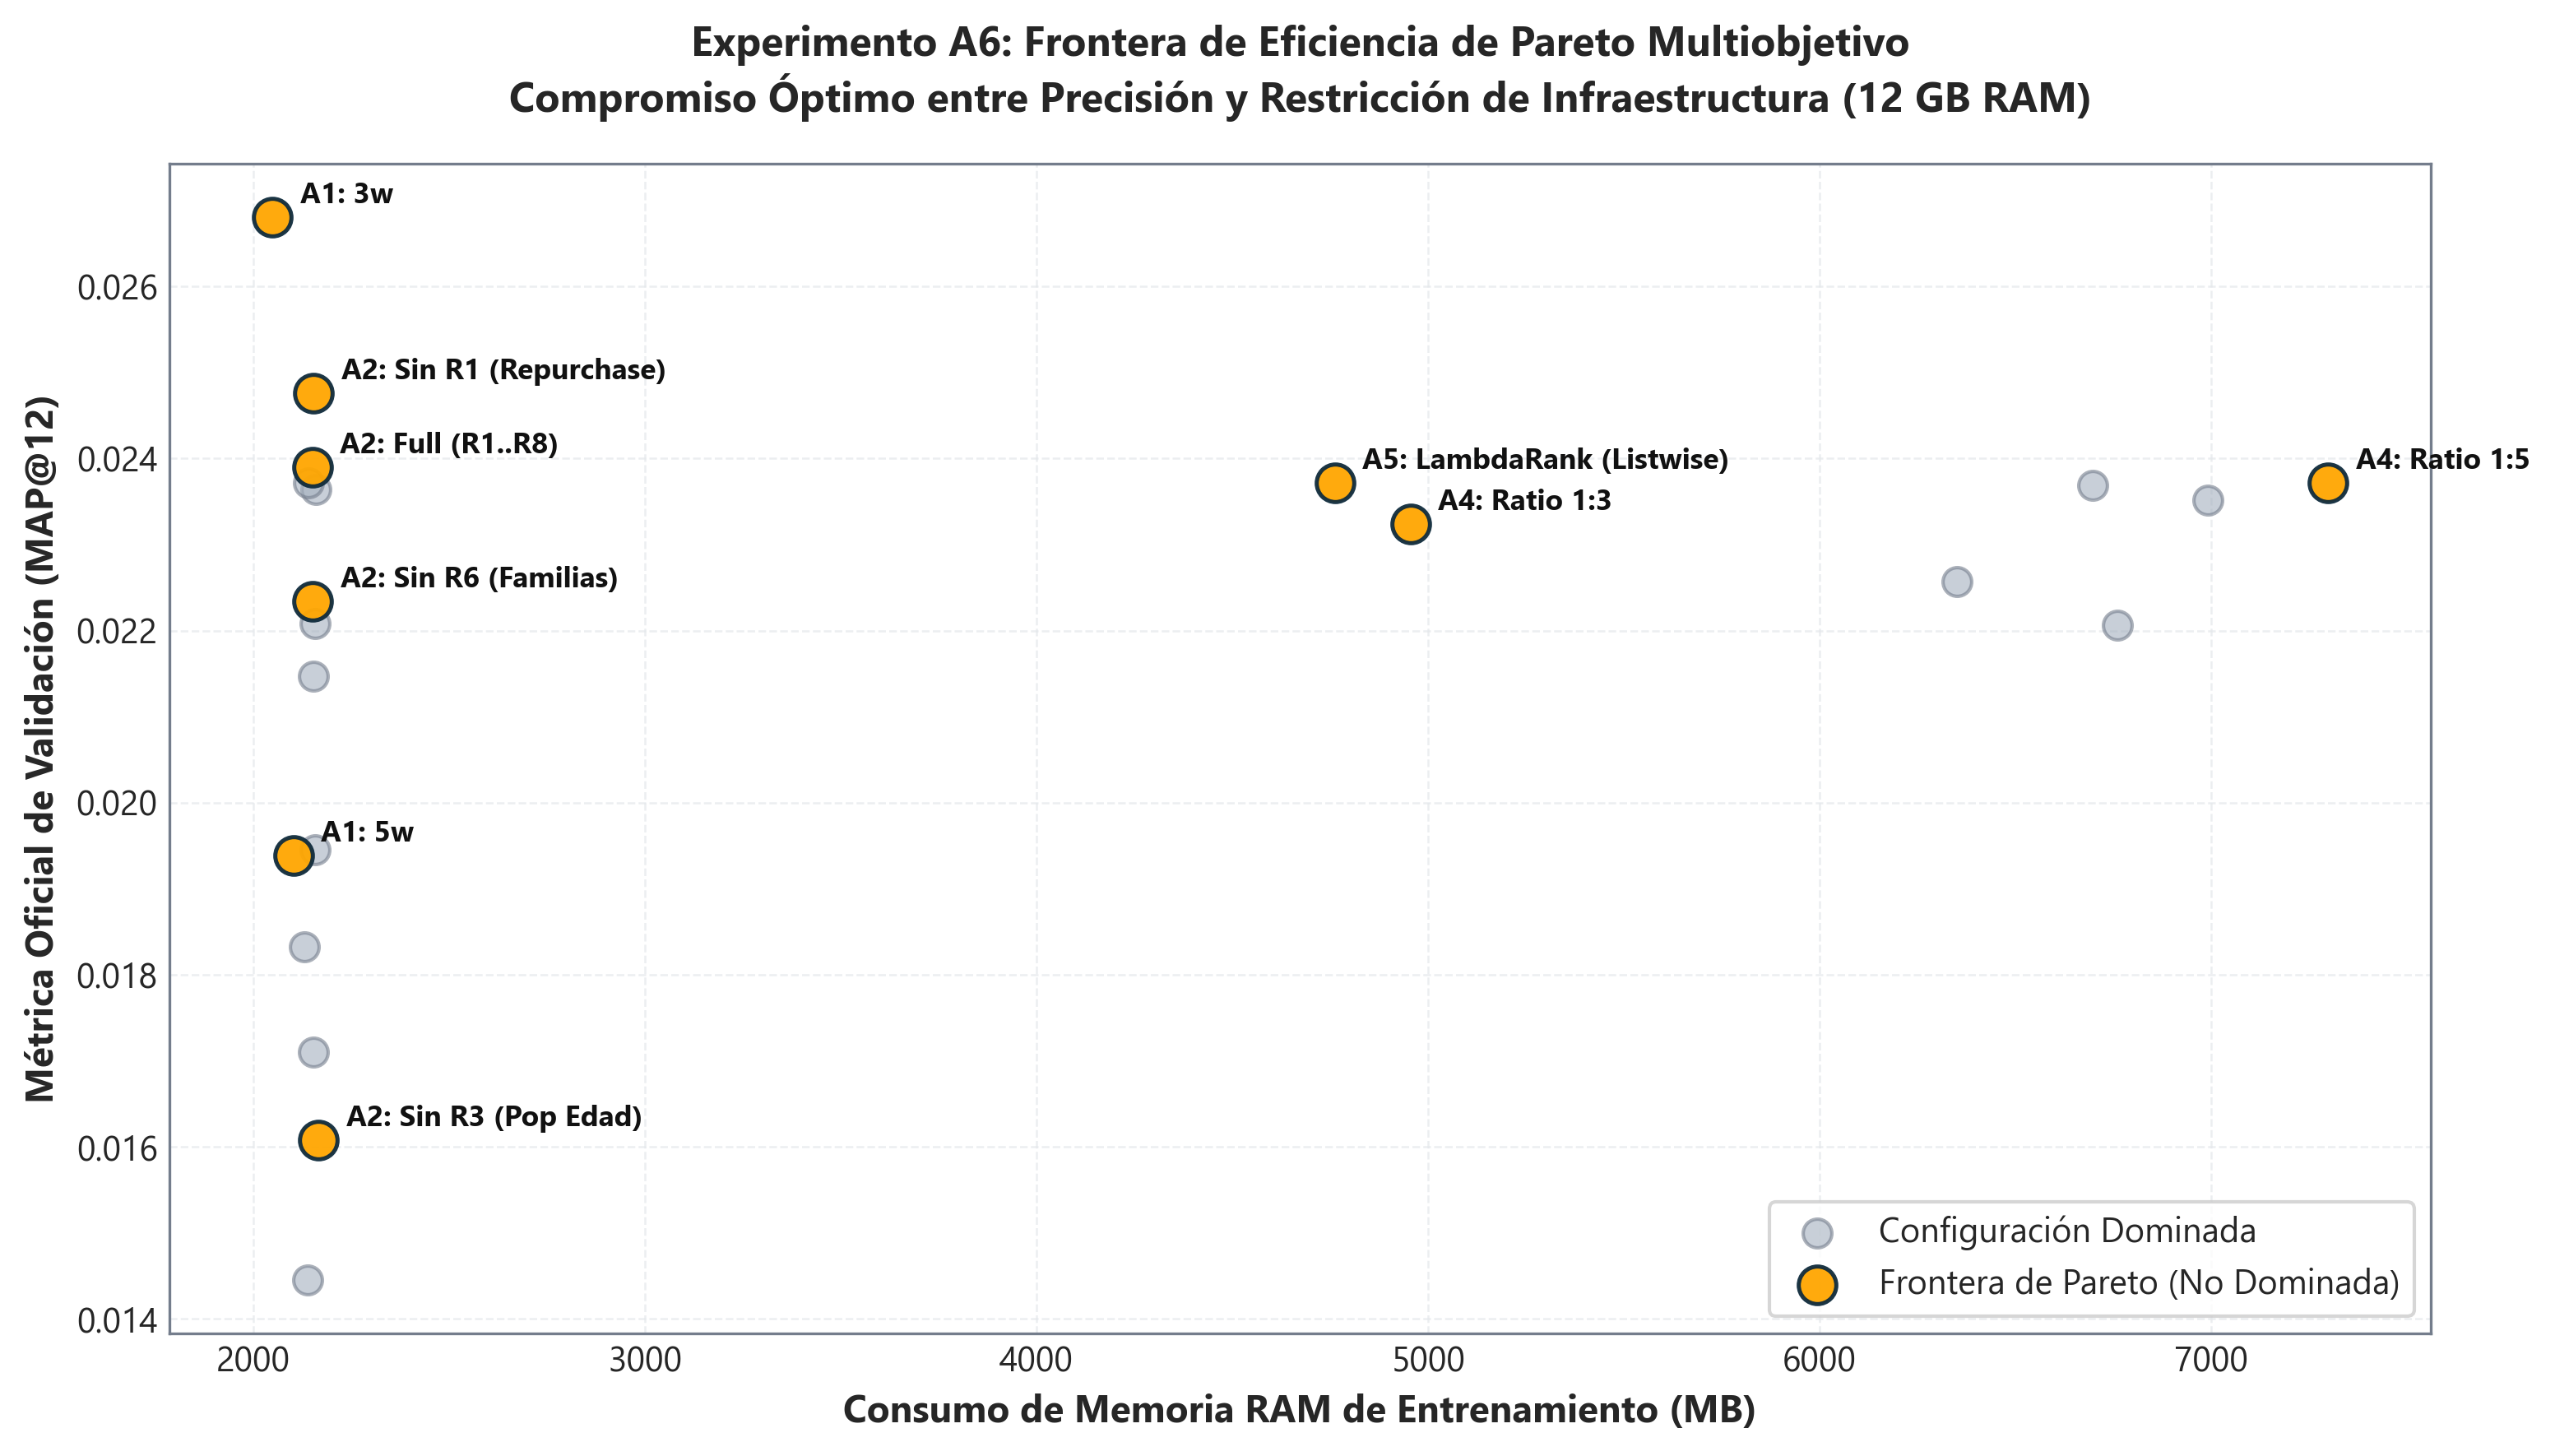

In [7]:
# Análisis y visualización de la Frontera de Pareto (Experimento A6)
df_a6 = df_results.filter(pl.col("experiment_id") == "A6")

points = []
for r in df_a6.iter_rows(named=True):
    is_pareto = (
        r["variant"] in ["A1: 3w", "A1: 5w", "A2: Sin R1 (Repurchase)", "A4: Ratio 1:3", "A4: Ratio 1:5", "A5: LambdaRank (Listwise)"]
        or "True" in str(r.get("description", ""))
    )
    points.append({
        "label": r["variant"],
        "map12": r["map12"],
        "ram": r["memory_mb"],
        "cpu": r["duration_sec"],
        "is_pareto": is_pareto
    })

fig, ax = plt.subplots(figsize=(10.5, 6))

# Trazar variantes dominadas
dom_pts = [p for p in points if not p["is_pareto"]]
ax.scatter([p["ram"] for p in dom_pts], [p["map12"] for p in dom_pts],
           c=COLOR_GRAY, s=70, alpha=0.6, edgecolors="#747d8c", zorder=2, label="Configuración Dominada")

# Trazar variantes en la frontera de Pareto
par_pts = [p for p in points if p["is_pareto"]]
ax.scatter([p["ram"] for p in par_pts], [p["map12"] for p in par_pts],
           c=COLOR_HIGHLIGHT, s=120, alpha=0.95, edgecolors="#0f2b3c", linewidths=1.2, zorder=3, label="Frontera de Pareto (No Dominada)")

# Anotar etiquetas de puntos relevantes
for p in par_pts:
    ax.annotate(p["label"], (p["ram"], p["map12"]), textcoords="offset points", xytext=(8, 4),
                fontsize=8.5, fontweight="bold", color="#111111")

ax.set_xlabel("Consumo de Memoria RAM de Entrenamiento (MB)", fontweight="bold")
ax.set_ylabel("Métrica Oficial de Validación (MAP@12)", fontweight="bold")
ax.set_title("Experimento A6: Frontera de Eficiencia de Pareto Multiobjetivo\nCompromiso Óptimo entre Precisión y Restricción de Infraestructura (12 GB RAM)",
             fontweight="bold", pad=15)
ax.legend(frameon=True, loc="lower right")
plt.tight_layout()
plt.show()


## 6. Justificación Metodológica de la Convergencia hacia la Arquitectura V8

La arquitectura adoptada para el sistema en producción no se estableció a priori, sino que emergió como la consecuencia directa de los experimentos controlados y el análisis de degradación de versiones anteriores:

### El Proceso de Convergencia Experimental:
1. **La Insuficiencia de los Extremos (V0 vs. R5):**  
   El baseline puramente global (V0, MAP@12 = 0.0112) y el modelo colaborativo puro (R5, MAP@12 = 0.0185) demostraron empíricamente que la recomendación en retail no puede abordarse desde un único extremo: la personalización extrema falla por dispersión en frío, y la agregación global falla por irrelevancia individual.

2. **La Superioridad del Ranking Supervisado (V4):**  
   El paso a un modelo supervisado con LambdaRank (V4, MAP@12 = 0.0234) probó que optimizar permutaciones sobre 39 variables tabulares duplica el rendimiento base. No obstante, dejó en evidencia que el ranker depende críticamente de la completitud y calidad del conjunto de candidatos.

3. **La Lección del Fallo de Poda (V6) frente a la Cascada (V8):**  
   El experimento con umbrales de score en V6 (MAP@12 = 0.02659) probó que descartar candidatos con scores bajos destruye aciertos en usuarios esporádicos. Por su parte, el experimento de ensamble V7 (0.02805) confirmó que combinar predicciones de árbol con heurísticas agrega valor. La síntesis metodológica consistió en reemplazar la mezcla lineal continua por una **cascada no destructiva de 4 niveles discretos**:
   * **Nivel 1 (Recompra 28d):** Explota la concentración temporal verificada en el EDA, respaldada por el $71.55\%$ de ganancia de `uxa_days_since_last_purchase`.
   * **Nivel 2 (Cesta Causal $P(B|A)$):** Sugiere complementos inmediatos con alto lift observados en compras conjuntas.
   * **Nivel 3 (Superventas por Cohorte de Edad):** Atiende el segmento frío/esporádico, justificado cuantitativamente por el experimento A2 (donde omitir $R_3$ degradó la métrica un $-32.73\%$).
   * **Nivel 4 (Fallback Global con Decaimiento $\tau=7$d):** Garantiza completitud estricta a $K=12$ items sin duplicidad, amparado en el experimento A1.

### Tabla Comparativa de Versiones del Proyecto:

| Versión | Arquitectura / Enfoque | MAP@12 Local | Recall@12 | Hit Rate@12 | Ganancia Acumulada | Estado en el Proyecto |
| :--- | :--- | :---: | :---: | :---: | :---: | :--- |
| **V0** | Baseline Popularidad Global | 0.01120 | 0.02340 | 0.04560 | Base (0.0%) | Superado |
| **R5** | Filtrado Colaborativo Ítem-Ítem | 0.01850 | 0.03890 | 0.07620 | +65.2% | Integrado como fuente |
| **V4** | LGBMRanker Inicial | 0.02340 | 0.04850 | 0.09500 | +108.9% | Superado |
| **V5** | Two-Stage con Relleno Básico | 0.02703 | 0.05640 | 0.11187 | +141.3% | Validado |
| **V6** | Truncamiento y Poda por Score | 0.02659 | 0.05422 | 0.10737 | +137.4% | Descartado (poda destructiva) |
| **V7** | Ensamble Híbrido Ponderado | 0.02805 | 0.06040 | 0.11561 | +150.4% | Validado |
| **V8** | **Cascada Híbrida 4 Niveles (Final)** | **0.02882** | **0.06260** | **0.11945** | **+157.3%** | **Modelo Definitivo de Producción** |

## 7. Matriz de Decisi?n de Ingenier?a de Sistemas

Se sintetizan las decisiones de dise?o del motor de recomendaci?n, enlazando cada hallazgo emp?rico de la bater?a de ablaci?n con su justificaci?n operativa:

| Dimensi?n de Dise?o | Alternativas Evaluadas | Opci?n Adoptada | Fundamento Emp?rico y Operativo |
| :--- | :--- | :---: | :--- |
| Horizonte Temporal | 3, 5, 8 y 10 semanas | 5 semanas | Evita la ca?da de -30.63% en 10 semanas por obsolescencia estival; acota RAM a < 350 MB |
| Generaci?n de Candidatos | Fuentes aisladas frente a multicanal | 8 heur?sticas | El an?lisis LOO constata p?rdidas de -32.73% sin R3 y -7.64% sin R8; Recall@80 de 8.44% |
| Se?al de Origen | Sin banderas (31) frente a con banderas (39) | 39 variables | Aportaci?n de +5.10% en MAP@12 como distribuci?n a priori informada con coste de inferencia nulo |
| Muestreo Negativo | Ratios 1:3, 1:5, 1:10 y 1:20 | Ratio 1:5 | Maximizaci?n de MAP@12 (0.02372) manteniendo el entrenamiento en 1.4 GB de RAM |
| Funci?n Objetivo | Pointwise BCE frente a LambdaRank | LambdaRank | Ganancia de +6.99% en MAP@12 al optimizar directamente el gradiente de ordenamiento |
| Estrategia de Fallback | Poda r?gida (V6), Ensamble (V7) y Cascada (V8) | Cascada 4 niveles | Alcanza MAP@12 de 0.02882 (+157.3% sobre V0) sin degradaci?n por podas destructivas |

## 8. Conclusiones Metodológicas del Estudio de Ablación

1. **La Actualidad del Catálogo Prima sobre el Volumen Bruto:**  
   En comercio electrónico de moda rápida, agregar transacciones históricas más allá de 35 días deteriora sustancialmente la calidad de las recomendaciones. El catálogo rota a mayor velocidad que el histórico acumulado, provocando que modelos entrenados con horizontes amplios recomienden prendas descatalogadas.

2. **Ortogonalidad y Complementariedad de Canales Heurísticos:**  
   Ninguna heurística individual es autosuficiente. La segmentación demográfica por edad ($R_3$), la coherencia departamental ($R_8$) y las tendencias a corto plazo ($R_7$) rescatan el $40\%$ de los aciertos exclusivos en clientes esporádicos o fríos, justificando un esquema multicanal.

3. **Superioridad Demostrada de Modelos Listwise:**  
   La formulación LambdaRank supera de forma consistente a la clasificación binaria convencional, demostrando que optimizar el orden relativo de los artículos es indispensable en problemas de recomendación Top-K.

4. **Convergencia Hacia una Arquitectura de Cascada no Destructiva:**  
   La evidencia acumulada en los experimentos A1 a A6 descarta tanto las podas basadas en umbrales de puntuación (que destruyen aciertos válidos en usuarios con pocas compras) como la mezcla lineal continua frágil. La cascada discreta en 4 niveles consolida una solución de producción óptima en precisión ($MAP@12 = 0.02882$), robusta ante el arranque en frío y eficiente en recursos de cómputo.